# Import Library dan Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Load dataset
# Ganti 'data_A.csv' dengan path lengkap file jika berbeda
file_path = 'data_A.csv'
df = pd.read_csv(file_path, index_col=0)  # index_col=0 karena ada kolom indeks di file

print("="*50)
print("INFORMASI AWAL DATASET")
print("="*50)
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")
print("\n5 Data Pertama:")
print(df.head())
print("\nInfo Dataset:")
df.info()
print("\nStatistik Deskriptif (Kolom Numerik):")
print(df.describe())

INFORMASI AWAL DATASET
Jumlah baris: 25000
Jumlah kolom: 28

5 Data Pertama:
        ID Customer_ID    Month            Name   Age          SSN Occupation  \
0   0xa658  CUS_0x936d    March  Alistair Barrs  8466  703-48-3482    _______   
1   0x6739  CUS_0x9a29   August           Phila    25  339-28-0072  Developer   
2   0xdcf5  CUS_0x12a9    April         Driverb    44  583-20-9758    _______   
3  0x14453  CUS_0x3bad     June         Prasadc    29  510-25-2095   Musician   
4  0x1198e  CUS_0xa3e1  January       Poornimai    45  943-92-4350  Scientist   

  Annual_Income  Monthly_Inhand_Salary  Num_Bank_Accounts  ...  Credit_Mix  \
0     100433.58            8074.465000                  1  ...        Good   
1      33119.82            3024.985000                 10  ...         Bad   
2      44822.21            3555.184167                  1  ...        Good   
3     142081.48           11771.123333                  6  ...    Standard   
4     19267.27_            1374.605833        

# Data Cleaning

In [2]:
# Mengganti nilai yang tidak valid atau missing
# Beberapa kolom memiliki nilai seperti '______', 'NM', '_', '!@9#%8', '__10000__'
missing_values = ['______', 'NM', '_', '!@9#%8', '__10000__', '?', '-', 'na', 'N/A', 'NULL']
df.replace(missing_values, np.nan, inplace=True)
print("Nilai missing telah diganti dengan NaN")

Nilai missing telah diganti dengan NaN


# pembersihan Data - Kolom Age, Annual_Income, Num_of_Loan

In [3]:
# Membersihkan kolom 'Age'
def clean_age(age):
    try:
        age_int = int(age)
        if age_int < 0 or age_int > 120:  # Asumsi rentang usia wajar
            return np.nan
        return age_int
    except (ValueError, TypeError):
        return np.nan

df['Age'] = df['Age'].apply(clean_age)

# Membersihkan kolom 'Annual_Income'
def clean_income(income):
    if isinstance(income, str):
        income = income.replace('_', '')  # Hilangkan underscore
    try:
        income_float = float(income)
        if income_float < 0:
            return np.nan
        return income_float
    except (ValueError, TypeError):
        return np.nan

df['Annual_Income'] = df['Annual_Income'].apply(clean_income)

# Membersihkan kolom 'Num_of_Loan'
def clean_loan(loan):
    if isinstance(loan, str):
        loan = loan.replace('_', '')
    try:
        loan_int = int(loan)
        if loan_int < 0:
            return np.nan
        return loan_int
    except (ValueError, TypeError):
        return np.nan

df['Num_of_Loan'] = df['Num_of_Loan'].apply(clean_loan)

print("Kolom Age, Annual_Income, dan Num_of_Loan telah dibersihkan")

Kolom Age, Annual_Income, dan Num_of_Loan telah dibersihkan


# Pembersihan Data - Kolom Num_of_Delayed_Payment, Changed_Credit_Limit, Num_Credit_Inquiries

In [4]:
# Membersihkan kolom 'Num_of_Delayed_Payment'
def clean_delayed_payment(val):
    if isinstance(val, str):
        val = val.replace('_', '')
    try:
        val_int = int(val)
        if val_int < 0:
            return np.nan
        return val_int
    except (ValueError, TypeError):
        return np.nan

df['Num_of_Delayed_Payment'] = df['Num_of_Delayed_Payment'].apply(clean_delayed_payment)

# Membersihkan kolom 'Changed_Credit_Limit'
def clean_credit_limit(val):
    if isinstance(val, str):
        val = val.replace('_', '')
    try:
        return float(val)
    except (ValueError, TypeError):
        return np.nan

df['Changed_Credit_Limit'] = df['Changed_Credit_Limit'].apply(clean_credit_limit)

# Membersihkan kolom 'Num_Credit_Inquiries'
def clean_credit_inquiries(val):
    if isinstance(val, str):
        val = val.replace('_', '')
    try:
        val_int = int(val)
        if val_int < 0:
            return np.nan
        return val_int
    except (ValueError, TypeError):
        return np.nan

df['Num_Credit_Inquiries'] = df['Num_Credit_Inquiries'].apply(clean_credit_inquiries)

print("Kolom Num_of_Delayed_Payment, Changed_Credit_Limit, dan Num_Credit_Inquiries telah dibersihkan")

Kolom Num_of_Delayed_Payment, Changed_Credit_Limit, dan Num_Credit_Inquiries telah dibersihkan


# Pembersihan Data - Kolom Amount_invested_monthly dan Monthly_Balance

In [5]:
# Membersihkan kolom 'Amount_invested_monthly'
def clean_invested(val):
    if isinstance(val, str):
        val = val.replace('_', '').replace('!@9#%8', '')
    try:
        return float(val)
    except (ValueError, TypeError):
        return np.nan

df['Amount_invested_monthly'] = df['Amount_invested_monthly'].apply(clean_invested)

# Membersihkan kolom 'Monthly_Balance'
def clean_balance(val):
    if isinstance(val, str):
        val = val.replace('_', '')
    try:
        return float(val)
    except (ValueError, TypeError):
        return np.nan

df['Monthly_Balance'] = df['Monthly_Balance'].apply(clean_balance)

print("Kolom Amount_invested_monthly dan Monthly_Balance telah dibersihkan")

Kolom Amount_invested_monthly dan Monthly_Balance telah dibersihkan


# Konversi Tipe Data ke Numerik

In [6]:
# Mengkonversi kolom yang seharusnya numerik ke tipe float/int
numeric_cols = [
    'Age', 'Annual_Income', 'Num_of_Loan', 'Num_of_Delayed_Payment',
    'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Amount_invested_monthly',
    'Monthly_Balance', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
    'Num_Credit_Card', 'Interest_Rate', 'Delay_from_due_date',
    'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Total_EMI_per_month'
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("Semua kolom numerik telah dikonversi")

Semua kolom numerik telah dikonversi


In [7]:
print("\n" + "="*50)
print("INFORMASI SETELAH PEMBERSIHAN DATA")
print("="*50)
print(f"Jumlah baris setelah pembersihan: {df.shape[0]}")
print(f"Jumlah kolom setelah pembersihan: {df.shape[1]}")
print("\nInfo Dataset Setelah Pembersihan:")
df.info()
print("\nStatistik Deskriptif (Kolom Numerik) Setelah Pembersihan:")
print(df.describe())


INFORMASI SETELAH PEMBERSIHAN DATA
Jumlah baris setelah pembersihan: 25000
Jumlah kolom setelah pembersihan: 28

Info Dataset Setelah Pembersihan:
<class 'pandas.core.frame.DataFrame'>
Index: 25000 entries, 0 to 24999
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        25000 non-null  object 
 1   Customer_ID               25000 non-null  object 
 2   Month                     25000 non-null  object 
 3   Name                      22440 non-null  object 
 4   Age                       23133 non-null  float64
 5   SSN                       25000 non-null  object 
 6   Occupation                25000 non-null  object 
 7   Annual_Income             25000 non-null  float64
 8   Monthly_Inhand_Salary     21417 non-null  float64
 9   Num_Bank_Accounts         25000 non-null  int64  
 10  Num_Credit_Card           25000 non-null  int64  
 11  Interest_Rate             25

# Analisis Distribusi Credit Score

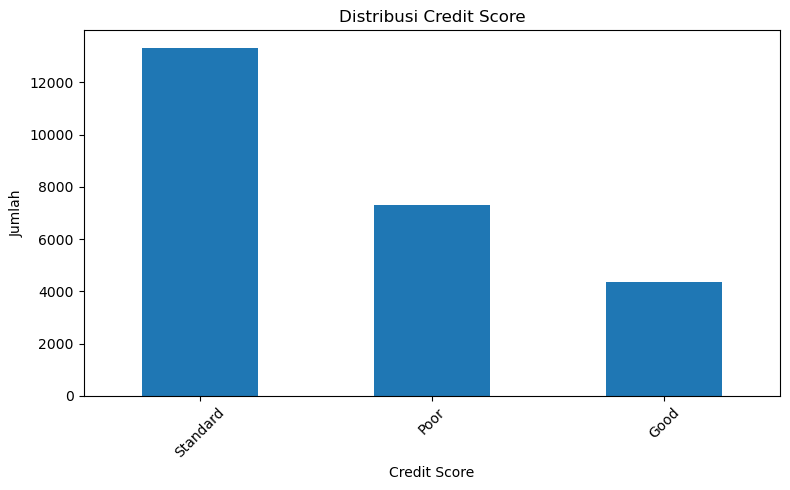

In [8]:
# Distribusi Credit Score
plt.figure(figsize=(8, 5))
df['Credit_Score'].value_counts().plot(kind='bar')
plt.title('Distribusi Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Jumlah')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Analisis Distribusi Pekerjaan

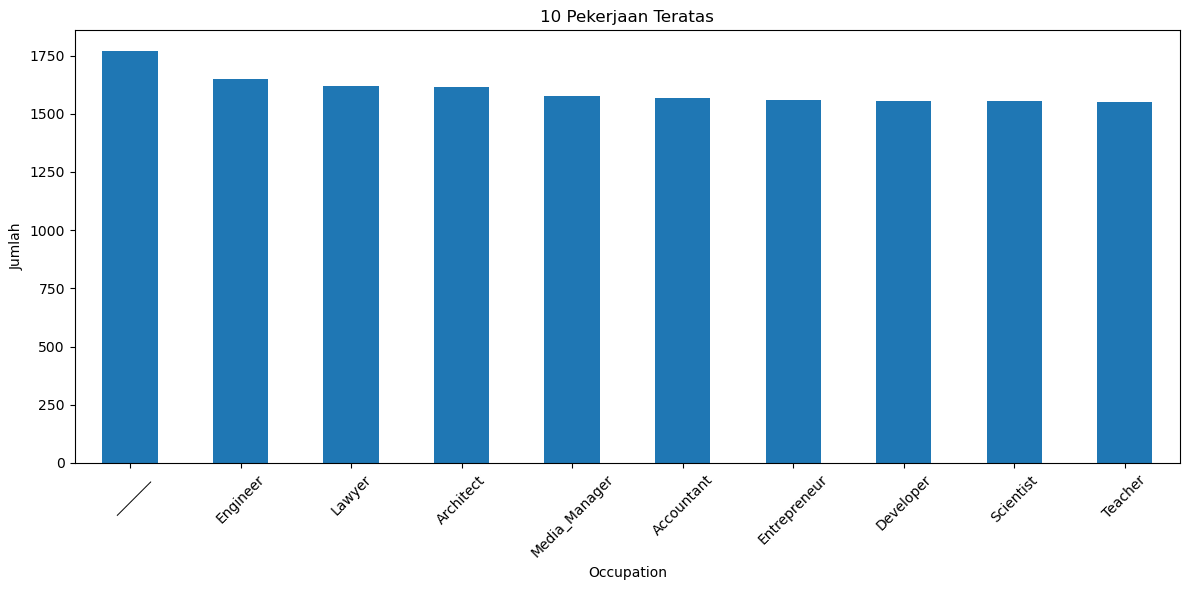

In [9]:
# 10 Pekerjaan Teratas
plt.figure(figsize=(12, 6))
df['Occupation'].value_counts().head(10).plot(kind='bar')
plt.title('10 Pekerjaan Teratas')
plt.xlabel('Occupation')
plt.ylabel('Jumlah')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Analisis Scatter Plot - Annual Income vs Outstanding Debt

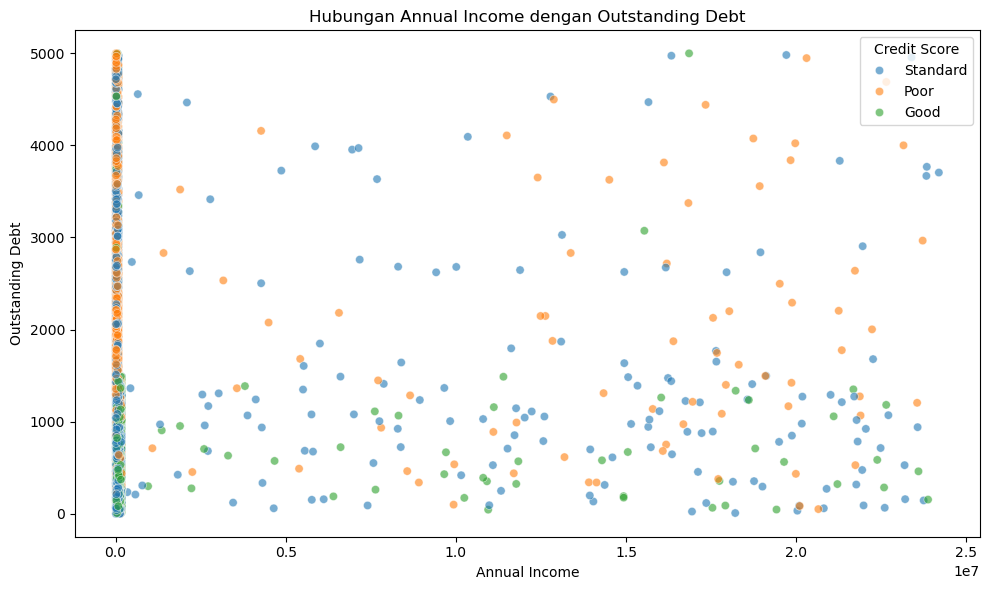

In [10]:
# Scatter Plot: Annual Income vs Outstanding Debt
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Annual_Income', y='Outstanding_Debt', hue='Credit_Score', alpha=0.6)
plt.title('Hubungan Annual Income dengan Outstanding Debt')
plt.xlabel('Annual Income')
plt.ylabel('Outstanding Debt')
plt.legend(title='Credit Score')
plt.tight_layout()
plt.show()

#  Analisis Boxplot - Interest Rate berdasarkan Credit Score

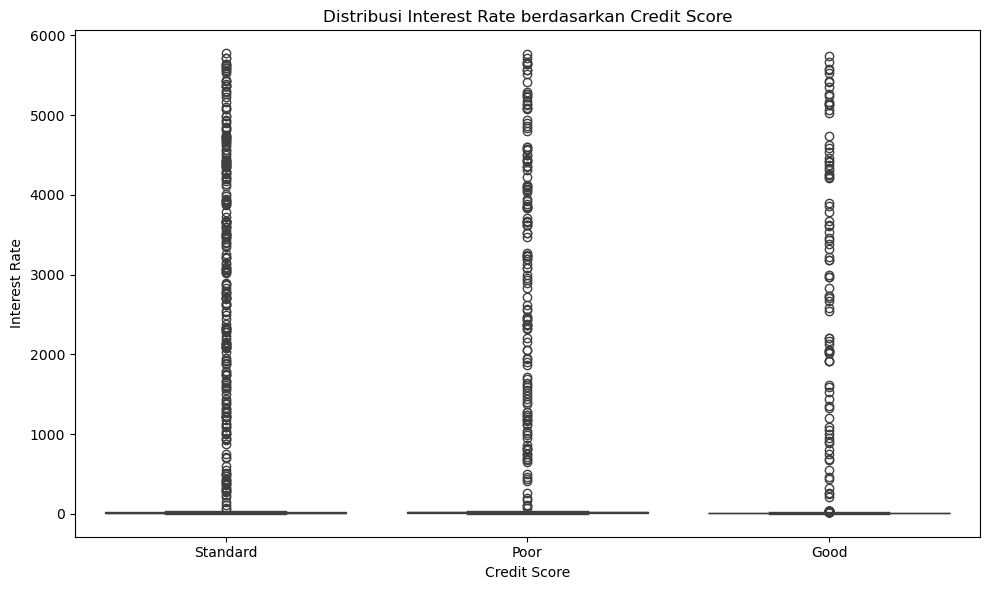

In [11]:
# Boxplot: Interest Rate berdasarkan Credit Score
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Credit_Score', y='Interest_Rate')
plt.title('Distribusi Interest Rate berdasarkan Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Interest Rate')
plt.tight_layout()
plt.show()

#  Analisis Heatmap Korelasi

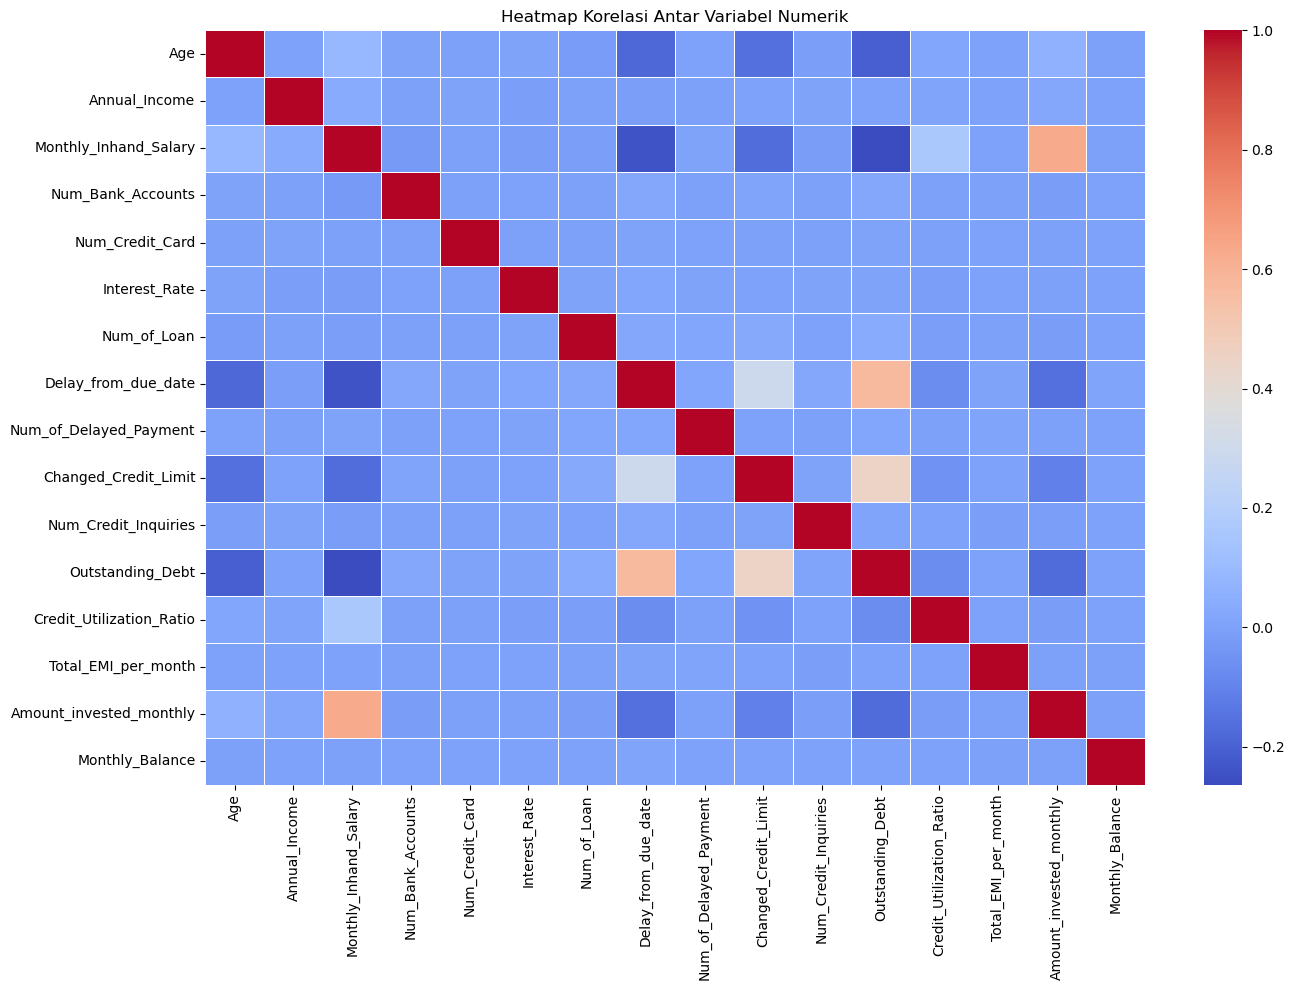

In [12]:
# Heatmap Korelasi (hanya kolom numerik)
plt.figure(figsize=(14, 10))
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap Korelasi Antar Variabel Numerik')
plt.tight_layout()
plt.show()

# Feature Engineering - Membuat Fitur Baru

In [13]:
# 1. Membuat fitur rasio hutang terhadap pendapatan
df['Debt_to_Income_Ratio'] = df['Outstanding_Debt'] / df['Annual_Income']

# 2. Membuat fitur rasio pembayaran minimum
df['Min_Payment_Ratio'] = df['Total_EMI_per_month'] / df['Monthly_Inhand_Salary']

# 3. Membuat fitur jumlah pinjaman per kategori (dari Type_of_Loan)
def count_loan_types(loan_str):
    if pd.isna(loan_str):
        return 0
    return len(str(loan_str).split(', '))

df['Num_Loan_Types'] = df['Type_of_Loan'].apply(count_loan_types)

# 4. Membuat fitur status pembayaran (Payment_Behaviour)
# Kita bisa mengkategorikan menjadi 3 kategori: Low, Medium, High
def categorize_payment(behaviour):
    if pd.isna(behaviour):
        return 'Unknown'
    if 'Low' in str(behaviour):
        return 'Low'
    elif 'Medium' in str(behaviour):
        return 'Medium'
    elif 'High' in str(behaviour):
        return 'High'
    else:
        return 'Other'

df['Payment_Category'] = df['Payment_Behaviour'].apply(categorize_payment)

# 5. Membuat fitur umur kredit dalam tahun (dari Credit_History_Age)
def extract_credit_years(age_str):
    if pd.isna(age_str):
        return np.nan
    try:
        # Format: "20 Years and 5 Months"
        parts = str(age_str).split(' Years')
        years = int(parts[0].strip())
        return years
    except:
        return np.nan

df['Credit_History_Years'] = df['Credit_History_Age'].apply(extract_credit_years)

print("Fitur-fitur baru telah dibuat")
print("\nBeberapa fitur baru:")
print(df[['Debt_to_Income_Ratio', 'Min_Payment_Ratio', 'Num_Loan_Types', 
          'Payment_Category', 'Credit_History_Years']].head())

Fitur-fitur baru telah dibuat

Beberapa fitur baru:
   Debt_to_Income_Ratio  Min_Payment_Ratio  Num_Loan_Types Payment_Category  \
0              0.010195           0.012405               2              Low   
1              0.076842           0.036834               5              Low   
2              0.016301           0.037985               4              Low   
3              0.006562           0.015344               3              Low   
4              0.196060           0.057438               6              Low   

   Credit_History_Years  
0                  20.0  
1                  14.0  
2                  23.0  
3                  27.0  
4                  10.0  


# Mengatasi Missing Value

In [14]:
# Melihat persentase missing value per kolom
missing_percentage = df.isnull().sum() / len(df) * 100
missing_df = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': missing_percentage
}).sort_values('Missing_Percentage', ascending=False)

print("Persentase Missing Value per Kolom:")
print(missing_df[missing_df['Missing_Count'] > 0])

# Strategi pengisian missing value
# 1. Kolom numerik - diisi dengan median
numeric_cols_for_impute = ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 
                          'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate',
                          'Delay_from_due_date', 'Outstanding_Debt', 
                          'Credit_Utilization_Ratio', 'Total_EMI_per_month',
                          'Amount_invested_monthly', 'Monthly_Balance',
                          'Changed_Credit_Limit', 'Num_Credit_Inquiries',
                          'Num_of_Loan', 'Num_of_Delayed_Payment',
                          'Debt_to_Income_Ratio', 'Min_Payment_Ratio',
                          'Credit_History_Years']

for col in numeric_cols_for_impute:
    if col in df.columns:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)

# 2. Kolom kategorikal - diisi dengan modus
categorical_cols = ['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 
                    'Payment_Behaviour', 'Payment_Category']

for col in categorical_cols:
    if col in df.columns:
        mode_val = df[col].mode()[0] if not df[col].mode().empty else 'Unknown'
        df[col] = df[col].fillna(mode_val)

# 3. Kolom 'Type_of_Loan' - diisi dengan 'None'
df['Type_of_Loan'] = df['Type_of_Loan'].fillna('None')

# 4. Kolom 'Credit_History_Age' - diisi dengan modus
df['Credit_History_Age'] = df['Credit_History_Age'].fillna(df['Credit_History_Age'].mode()[0])

print("\nMissing value telah diisi")
print(f"Jumlah missing value setelah imputasi: {df.isnull().sum().sum()}")

Persentase Missing Value per Kolom:
                         Missing_Count  Missing_Percentage
Credit_Mix                        5066              20.264
Min_Payment_Ratio                 3583              14.332
Monthly_Inhand_Salary             3583              14.332
Payment_of_Min_Amount             3000              12.000
Type_of_Loan                      2828              11.312
Name                              2560              10.240
Credit_History_Years              2249               8.996
Credit_History_Age                2249               8.996
Amount_invested_monthly           2199               8.796
Num_of_Delayed_Payment            1889               7.556
Age                               1867               7.468
Payment_Behaviour                 1852               7.408
Num_of_Loan                        979               3.916
Changed_Credit_Limit               518               2.072
Num_Credit_Inquiries               506               2.024
Monthly_Balance     

# Encoding Data Kategorikal

In [15]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

# 1. Label Encoding untuk target (Credit_Score)
le_target = LabelEncoder()
df['Credit_Score_Encoded'] = le_target.fit_transform(df['Credit_Score'])
# Mapping: Good=0, Poor=1, Standard=2 (sesuai urutan alfabet)

print("Mapping Credit_Score:")
for i, label in enumerate(le_target.classes_):
    print(f"{label}: {i}")

# 2. One-Hot Encoding untuk beberapa fitur kategorikal
categorical_features = ['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 
                        'Payment_Category']

# Menggunakan ColumnTransformer untuk One-Hot Encoding
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ],
    remainder='passthrough'
)

# Untuk demonstrasi, kita akan membuat dataframe hasil encoding
# Tapi untuk modeling, kita akan menggunakan pipeline nanti
from sklearn.pipeline import Pipeline

print("\nFitur-fitur kategorikal akan di-encode dalam pipeline modeling")

Mapping Credit_Score:
Good: 0
Poor: 1
Standard: 2

Fitur-fitur kategorikal akan di-encode dalam pipeline modeling


# Persiapan Data untuk Modeling 

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# 1. Memilih fitur untuk modeling
# Fitur numerik
numeric_features = ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 
                   'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate',
                   'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment',
                   'Changed_Credit_Limit', 'Num_Credit_Inquiries',
                   'Outstanding_Debt', 'Credit_Utilization_Ratio',
                   'Total_EMI_per_month', 'Amount_invested_monthly',
                   'Monthly_Balance', 'Debt_to_Income_Ratio', 
                   'Min_Payment_Ratio', 'Credit_History_Years']

# Fitur kategorikal
categorical_features = ['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount',
                        'Payment_Category']

# 2. Membuat pipeline preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features)
    ])

# 3. Memisahkan fitur dan target
X = df[numeric_features + categorical_features]
y = df['Credit_Score_Encoded']

# 4. Split data training dan testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Ukuran data training: {X_train.shape}")
print(f"Ukuran data testing: {X_test.shape}")
print("\nDistribusi target pada data training:")
print(pd.Series(y_train).value_counts())
print("\nDistribusi target pada data testing:")
print(pd.Series(y_test).value_counts())

Ukuran data training: (20000, 23)
Ukuran data testing: (5000, 23)

Distribusi target pada data training:
Credit_Score_Encoded
2    10664
1     5842
0     3494
Name: count, dtype: int64

Distribusi target pada data testing:
Credit_Score_Encoded
2    2666
1    1460
0     874
Name: count, dtype: int64


# Modeling - Logistic Regression (Baseline)

EVALUASI LOGISTIC REGRESSION
Akurasi: 0.6182

Classification Report:
              precision    recall  f1-score   support

        Good       0.52      0.55      0.54       874
        Poor       0.63      0.42      0.51      1460
    Standard       0.64      0.75      0.69      2666

    accuracy                           0.62      5000
   macro avg       0.60      0.57      0.58      5000
weighted avg       0.62      0.62      0.61      5000



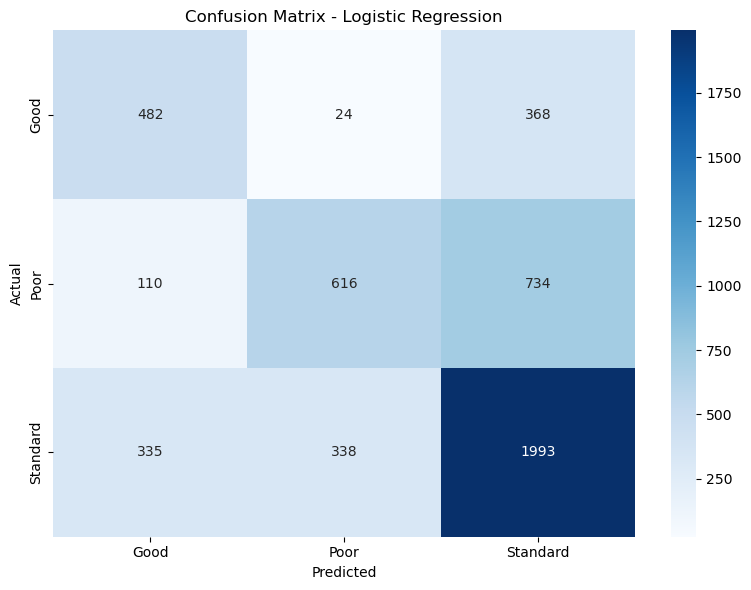

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Membuat pipeline dengan Logistic Regression
model_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# 2. Training model
model_lr.fit(X_train, y_train)

# 3. Prediksi
y_pred_lr = model_lr.predict(X_test)

# 4. Evaluasi
print("="*50)
print("EVALUASI LOGISTIC REGRESSION")
print("="*50)
print(f"Akurasi: {accuracy_score(y_test, y_pred_lr):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=le_target.classes_))

# 5. Confusion Matrix
plt.figure(figsize=(8, 6))
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_)
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Modeling - Random Forest

EVALUASI RANDOM FOREST
Akurasi: 0.7484

Classification Report:
              precision    recall  f1-score   support

        Good       0.65      0.65      0.65       874
        Poor       0.77      0.73      0.75      1460
    Standard       0.77      0.79      0.78      2666

    accuracy                           0.75      5000
   macro avg       0.73      0.72      0.73      5000
weighted avg       0.75      0.75      0.75      5000


Top 10 Fitur Terpenting:
                     Feature  Importance
11          Outstanding_Debt    0.103295
5              Interest_Rate    0.071185
7        Delay_from_due_date    0.059932
9       Changed_Credit_Limit    0.056778
16      Debt_to_Income_Ratio    0.051537
12  Credit_Utilization_Ratio    0.046373
14   Amount_invested_monthly    0.046298
4            Num_Credit_Card    0.043109
8     Num_of_Delayed_Payment    0.041420
1              Annual_Income    0.041217


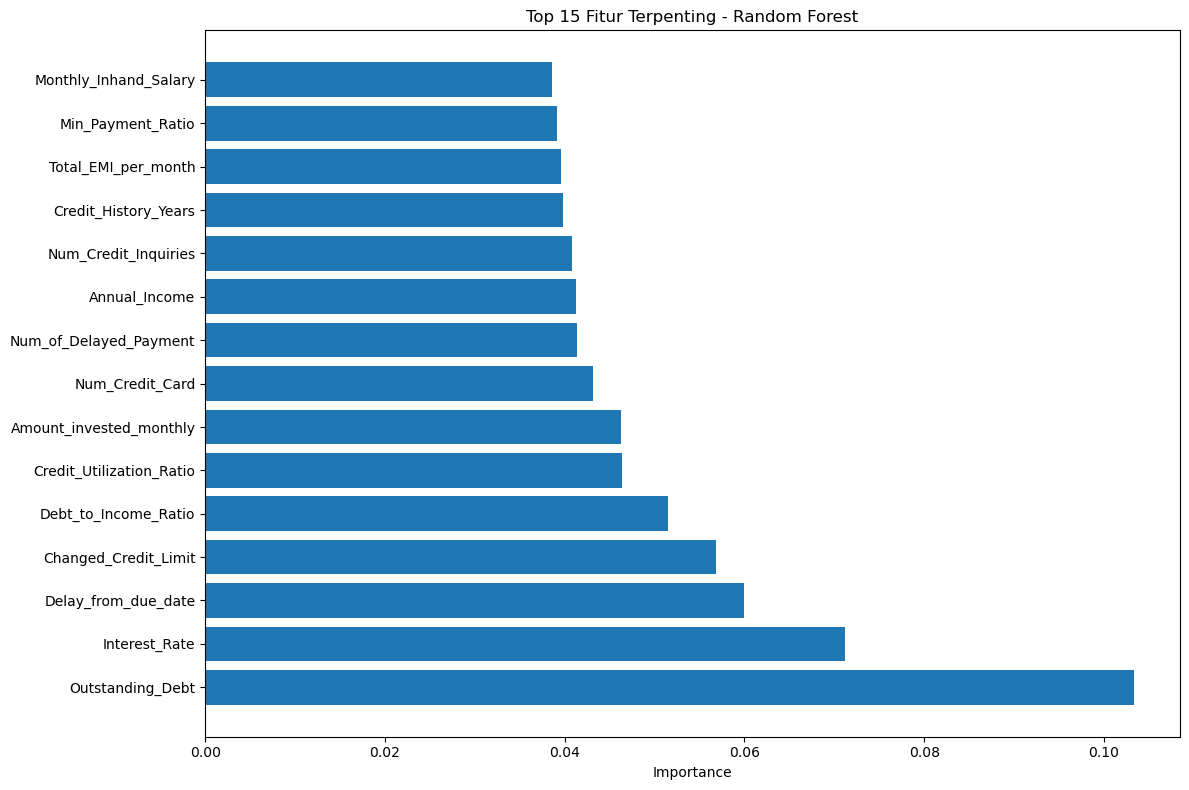

In [18]:
from sklearn.ensemble import RandomForestClassifier

# 1. Membuat pipeline dengan Random Forest
model_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# 2. Training model
model_rf.fit(X_train, y_train)

# 3. Prediksi
y_pred_rf = model_rf.predict(X_test)

# 4. Evaluasi
print("="*50)
print("EVALUASI RANDOM FOREST")
print("="*50)
print(f"Akurasi: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=le_target.classes_))

# 5. Feature Importance
feature_names = numeric_features + list(
    model_rf.named_steps['preprocessor']
    .named_transformers_['cat']
    .get_feature_names_out(categorical_features)
)

importance = model_rf.named_steps['classifier'].feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
}).sort_values('Importance', ascending=False)

print("\nTop 10 Fitur Terpenting:")
print(feature_importance_df.head(10))

# 6. Visualisasi Feature Importance
plt.figure(figsize=(12, 8))
top_features = feature_importance_df.head(15)
plt.barh(top_features['Feature'], top_features['Importance'])
plt.title('Top 15 Fitur Terpenting - Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# Modeling - XGBoost


In [19]:
# Install xgboost jika belum terinstall
# !pip install xgboost

from xgboost import XGBClassifier

# 1. Membuat pipeline dengan XGBoost
model_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss'))
])

# 2. Training model
model_xgb.fit(X_train, y_train)

# 3. Prediksi
y_pred_xgb = model_xgb.predict(X_test)

# 4. Evaluasi
print("="*50)
print("EVALUASI XGBOOST")
print("="*50)
print(f"Akurasi: {accuracy_score(y_test, y_pred_xgb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=le_target.classes_))

EVALUASI XGBOOST
Akurasi: 0.7306

Classification Report:
              precision    recall  f1-score   support

        Good       0.64      0.60      0.62       874
        Poor       0.75      0.70      0.72      1460
    Standard       0.75      0.79      0.77      2666

    accuracy                           0.73      5000
   macro avg       0.71      0.70      0.70      5000
weighted avg       0.73      0.73      0.73      5000



# Perbandingan Model

PERBANDINGAN AKURASI MODEL
                 Model  Accuracy
0  Logistic Regression    0.6182
1        Random Forest    0.7484
2              XGBoost    0.7306


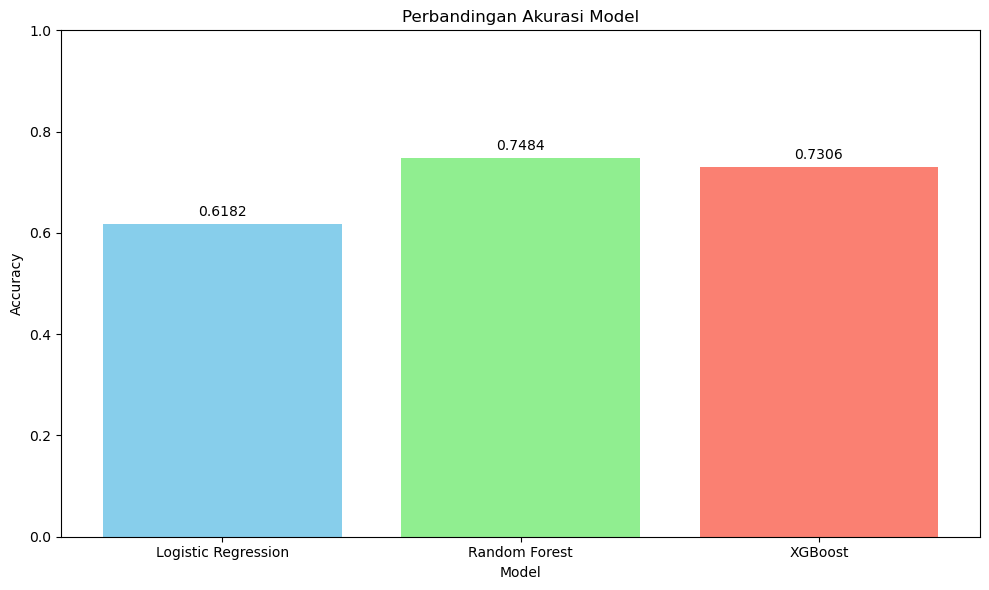

In [20]:
# Mengumpulkan hasil evaluasi
results = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ]
}

results_df = pd.DataFrame(results)
print("="*50)
print("PERBANDINGAN AKURASI MODEL")
print("="*50)
print(results_df)

# Visualisasi perbandingan
plt.figure(figsize=(10, 6))
bars = plt.bar(results_df['Model'], results_df['Accuracy'], 
               color=['skyblue', 'lightgreen', 'salmon'])
plt.ylim(0, 1)
plt.title('Perbandingan Akurasi Model')
plt.ylabel('Accuracy')
plt.xlabel('Model')

# Menambahkan nilai di atas bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Analisis Lebih Lanjut - Insight dari Data

RATA-RATA CREDIT SCORE PER PEKERJAAN
Occupation
Scientist       1.319382
Manager         1.321645
Entrepreneur    1.330340
Engineer        1.339394
Teacher         1.347294
Doctor          1.349572
Developer       1.353470
Accountant      1.356915
Musician        1.357531
Journalist      1.357846
Name: Credit_Score_Encoded, dtype: float64

RATA-RATA CREDIT SCORE PER PAYMENT BEHAVIOUR
Payment_Category
High       1.344547
Unknown    1.348272
Medium     1.352071
Low        1.369252
Name: Credit_Score_Encoded, dtype: float64

KORELASI FITUR DENGAN CREDIT SCORE
Credit_History_Years       -0.098886
Amount_invested_monthly    -0.069988
Monthly_Inhand_Salary      -0.060436
Age                        -0.046711
Credit_Utilization_Ratio   -0.019408
Monthly_Balance            -0.006507
Interest_Rate              -0.005554
Annual_Income              -0.002496
Num_Bank_Accounts           0.000240
Num_Credit_Card             0.000798
Num_Credit_Inquiries        0.001175
Total_EMI_per_month         0.

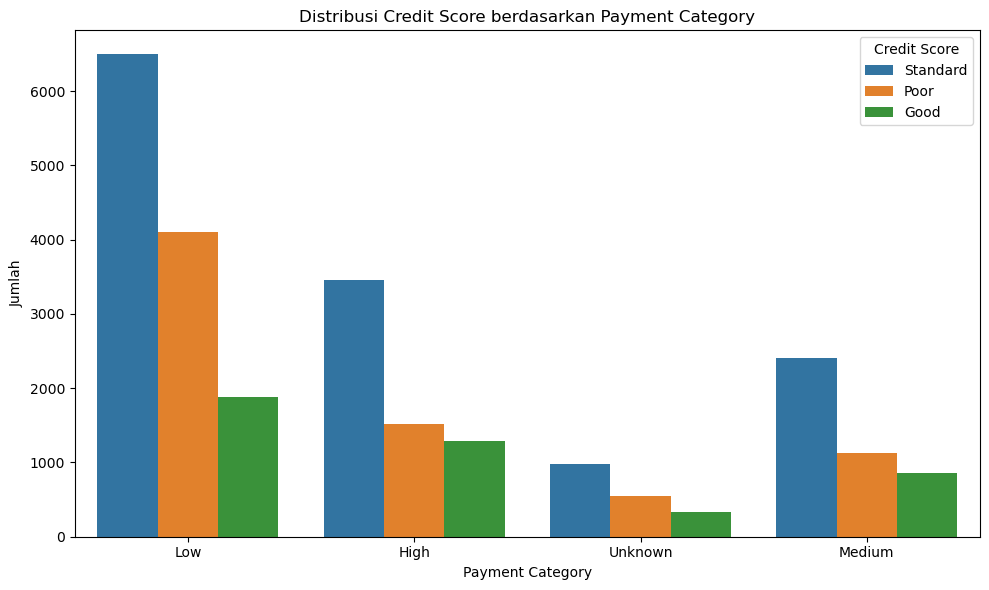

In [21]:
# 1. Analisis Credit Score berdasarkan Occupation
print("="*50)
print("RATA-RATA CREDIT SCORE PER PEKERJAAN")
print("="*50)
occupation_score = df.groupby('Occupation')['Credit_Score_Encoded'].mean().sort_values()
print(occupation_score.head(10))

# 2. Analisis Credit Score berdasarkan Payment Behaviour
print("\n" + "="*50)
print("RATA-RATA CREDIT SCORE PER PAYMENT BEHAVIOUR")
print("="*50)
payment_score = df.groupby('Payment_Category')['Credit_Score_Encoded'].mean().sort_values()
print(payment_score)

# 3. Analisis Correlation dengan Credit Score
print("\n" + "="*50)
print("KORELASI FITUR DENGAN CREDIT SCORE")
print("="*50)
correlation_with_target = df[numeric_features + ['Credit_Score_Encoded']].corr()['Credit_Score_Encoded'].sort_values()
print(correlation_with_target)

# 4. Visualisasi distribusi Credit Score berdasarkan Payment Category
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Payment_Category', hue='Credit_Score')
plt.title('Distribusi Credit Score berdasarkan Payment Category')
plt.xlabel('Payment Category')
plt.ylabel('Jumlah')
plt.legend(title='Credit Score')
plt.tight_layout()
plt.show()

# Hyperparameter Tuning dengan GridSearchCV (Random Forest)

In [22]:
from sklearn.model_selection import GridSearchCV

# Parameter grid untuk Random Forest
param_grid_rf = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [10, 20, 30, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

# GridSearchCV
grid_search_rf = GridSearchCV(
    model_rf,
    param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("Melakukan Grid Search untuk Random Forest...")
grid_search_rf.fit(X_train, y_train)

print(f"\nParameter terbaik: {grid_search_rf.best_params_}")
print(f"Akurasi terbaik (CV): {grid_search_rf.best_score_:.4f}")

# Evaluasi model terbaik
best_rf = grid_search_rf.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)
print(f"Akurasi pada test set: {accuracy_score(y_test, y_pred_best_rf):.4f}")

Melakukan Grid Search untuk Random Forest...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Parameter terbaik: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
Akurasi terbaik (CV): 0.7263
Akurasi pada test set: 0.7460


# Hyperparameter Tuning dengan GridSearchCV (XGBoost)

In [23]:
# Parameter grid untuk XGBoost
param_grid_xgb = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.1, 0.3],
    'classifier__subsample': [0.8, 1.0],
    'classifier__colsample_bytree': [0.8, 1.0]
}

# GridSearchCV
grid_search_xgb = GridSearchCV(
    model_xgb,
    param_grid_xgb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("Melakukan Grid Search untuk XGBoost...")
grid_search_xgb.fit(X_train, y_train)

print(f"\nParameter terbaik: {grid_search_xgb.best_params_}")
print(f"Akurasi terbaik (CV): {grid_search_xgb.best_score_:.4f}")

# Evaluasi model terbaik
best_xgb = grid_search_xgb.best_estimator_
y_pred_best_xgb = best_xgb.predict(X_test)
print(f"Akurasi pada test set: {accuracy_score(y_test, y_pred_best_xgb):.4f}")

Melakukan Grid Search untuk XGBoost...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Parameter terbaik: {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 7, 'classifier__n_estimators': 200, 'classifier__subsample': 0.8}
Akurasi terbaik (CV): 0.7188
Akurasi pada test set: 0.7418


# Perbandingan Model Setelah Tuning

PERBANDINGAN AKURASI MODEL (SETELAH TUNING)
                     Model  Accuracy
0      Logistic Regression    0.6182
1  Random Forest (Default)    0.7484
2    Random Forest (Tuned)    0.7460
3        XGBoost (Default)    0.7306
4          XGBoost (Tuned)    0.7418


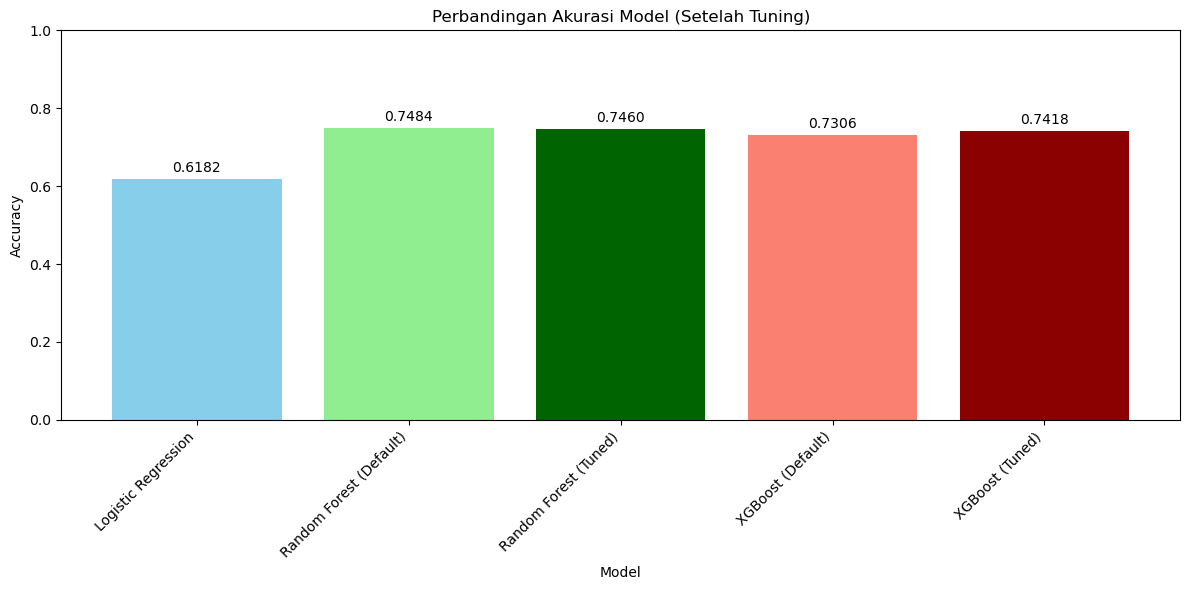

In [24]:
# Mengumpulkan hasil evaluasi setelah tuning
results_tuning = {
    'Model': ['Logistic Regression', 'Random Forest (Default)', 'Random Forest (Tuned)', 
              'XGBoost (Default)', 'XGBoost (Tuned)'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_best_rf),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_best_xgb)
    ]
}

results_tuning_df = pd.DataFrame(results_tuning)
print("="*50)
print("PERBANDINGAN AKURASI MODEL (SETELAH TUNING)")
print("="*50)
print(results_tuning_df)

# Visualisasi perbandingan
plt.figure(figsize=(12, 6))
bars = plt.bar(results_tuning_df['Model'], results_tuning_df['Accuracy'], 
               color=['skyblue', 'lightgreen', 'darkgreen', 'salmon', 'darkred'])
plt.ylim(0, 1)
plt.title('Perbandingan Akurasi Model (Setelah Tuning)')
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.xticks(rotation=45, ha='right')

# Menambahkan nilai di atas bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Analisis Error (Misclassification)

In [25]:
# Identifikasi data yang salah diklasifikasikan
misclassified = X_test.copy()
misclassified['Actual'] = y_test
misclassified['Predicted'] = y_pred_best_rf
misclassified['Actual_Label'] = le_target.inverse_transform(y_test)
misclassified['Predicted_Label'] = le_target.inverse_transform(y_pred_best_rf)
misclassified['Is_Correct'] = y_test == y_pred_best_rf

# Data yang salah prediksi
errors = misclassified[~misclassified['Is_Correct']]
print(f"Jumlah data yang salah prediksi: {len(errors)}")
print(f"Persentase error: {len(errors)/len(misclassified)*100:.2f}%")

print("\nContoh data yang salah prediksi (5 data pertama):")
print(errors[['Actual_Label', 'Predicted_Label'] + numeric_features[:5]].head())

# Analisis pola error per kategori
print("\nDistribusi error berdasarkan Credit Score actual:")
print(errors['Actual_Label'].value_counts())

print("\nDistribusi error berdasarkan Credit Score prediksi:")
print(errors['Predicted_Label'].value_counts())

Jumlah data yang salah prediksi: 1270
Persentase error: 25.40%

Contoh data yang salah prediksi (5 data pertama):
      Actual_Label Predicted_Label   Age  Annual_Income  \
16637     Standard            Poor  31.0      10210.735   
21756         Poor        Standard  35.0      20302.590   
9438          Good        Standard  22.0     134499.840   
16650         Poor            Good  26.0     118124.480   
7947      Standard            Poor  24.0       9955.465   

       Monthly_Inhand_Salary  Num_Bank_Accounts  Num_Credit_Card  
16637             733.894583                 10                9  
21756            3111.437500                  6             1242  
9438            11019.320000                  0                4  
16650            9559.706667                  3                3  
7947             3111.437500                166               10  

Distribusi error berdasarkan Credit Score actual:
Actual_Label
Standard    569
Poor        382
Good        319
Name: count, dtyp

# Confusion Matrix untuk Model Terbaik

<Figure size 800x600 with 0 Axes>

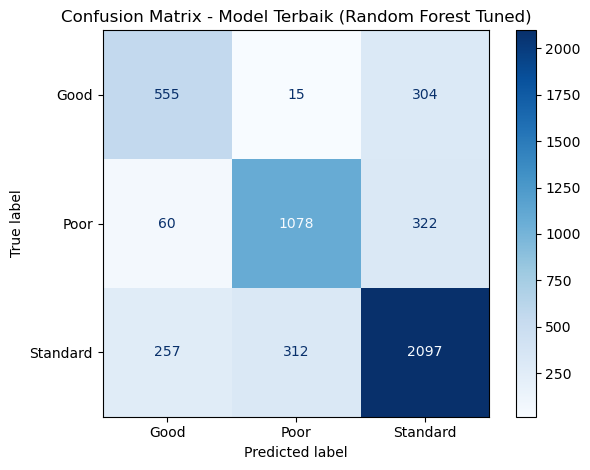


Metrik per kelas:
              precision    recall  f1-score   support

        Good       0.64      0.64      0.64       874
        Poor       0.77      0.74      0.75      1460
    Standard       0.77      0.79      0.78      2666

    accuracy                           0.75      5000
   macro avg       0.72      0.72      0.72      5000
weighted avg       0.75      0.75      0.75      5000



In [26]:
# Confusion Matrix untuk model terbaik (setelah tuning)
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(8, 6))
cm_best = confusion_matrix(y_test, y_pred_best_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_best, 
                              display_labels=le_target.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Model Terbaik (Random Forest Tuned)')
plt.tight_layout()
plt.show()

# Metrik tambahan: Precision, Recall, F1-Score per kelas
print("\nMetrik per kelas:")
print(classification_report(y_test, y_pred_best_rf, target_names=le_target.classes_))

#  Cross-Validation Score

In [27]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Cross-validation untuk model terbaik
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_rf, X_train, y_train, cv=cv, scoring='accuracy')

print("="*50)
print("CROSS-VALIDATION SCORE - MODEL TERBAIK")
print("="*50)
print(f"CV Scores: {cv_scores}")
print(f"Mean CV Score: {cv_scores.mean():.4f}")
print(f"Std CV Score: {cv_scores.std():.4f}")

CROSS-VALIDATION SCORE - MODEL TERBAIK
CV Scores: [0.72625 0.72    0.7185  0.71775 0.74075]
Mean CV Score: 0.7247
Std CV Score: 0.0086


# Fungsi Prediksi untuk Data Baru

In [28]:
def predict_credit_score(model, encoder, new_data):
    """
    Fungsi untuk memprediksi Credit Score pada data baru
    
    Parameters:
    - model: model yang sudah dilatih (pipeline)
    - encoder: LabelEncoder untuk Credit Score
    - new_data: DataFrame dengan data baru
    
    Returns:
    - prediksi label Credit Score
    """
    # Pastikan fitur-fitur yang diperlukan ada
    required_features = numeric_features + categorical_features
    for feature in required_features:
        if feature not in new_data.columns:
            raise ValueError(f"Fitur '{feature}' tidak ditemukan dalam data")
    
    # Prediksi
    predictions_encoded = model.predict(new_data[required_features])
    predictions_labels = encoder.inverse_transform(predictions_encoded)
    
    # Probabilitas (jika model mendukung)
    try:
        probabilities = model.predict_proba(new_data[required_features])
        return predictions_labels, probabilities
    except:
        return predictions_labels, None

# Contoh penggunaan (dengan data test)
sample_data = X_test.head(5)
pred_labels, pred_probs = predict_credit_score(best_rf, le_target, sample_data)

print("Contoh Prediksi pada 5 Data Test:")
print("="*50)
print("Prediksi Credit Score:")
print(pred_labels)
if pred_probs is not None:
    print("\nProbabilitas:")
    print(pred_probs)

Contoh Prediksi pada 5 Data Test:
Prediksi Credit Score:
['Poor' 'Poor' 'Standard' 'Poor' 'Standard']

Probabilitas:
[[0.    0.855 0.145]
 [0.03  0.495 0.475]
 [0.045 0.475 0.48 ]
 [0.005 0.57  0.425]
 [0.395 0.13  0.475]]


# Export Hasil Analisis ke Excel

In [29]:
# Membuat Excel writer
with pd.ExcelWriter('credit_score_analysis_report.xlsx') as writer:
    
    # 1. Data yang sudah dibersihkan
    df.to_excel(writer, sheet_name='Cleaned_Data', index=False)
    
    # 2. Statistik deskriptif
    df.describe().to_excel(writer, sheet_name='Descriptive_Stats')
    
    # 3. Hasil prediksi
    results_df = X_test.copy()
    results_df['Actual_Credit_Score'] = le_target.inverse_transform(y_test)
    results_df['Predicted_Credit_Score'] = le_target.inverse_transform(y_pred_best_rf)
    results_df.to_excel(writer, sheet_name='Predictions', index=False)
    
    # 4. Feature Importance
    feature_names = numeric_features + list(
        best_rf.named_steps['preprocessor']
        .named_transformers_['cat']
        .get_feature_names_out(categorical_features)
    )
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': best_rf.named_steps['classifier'].feature_importances_
    }).sort_values('Importance', ascending=False)
    importance_df.to_excel(writer, sheet_name='Feature_Importance', index=False)
    
    # 5. Model performance summary
    performance_df = pd.DataFrame({
        'Model': ['Random Forest (Tuned)'],
        'Accuracy': [accuracy_score(y_test, y_pred_best_rf)],
        'CV_Mean': [cv_scores.mean()],
        'CV_Std': [cv_scores.std()]
    })
    performance_df.to_excel(writer, sheet_name='Model_Performance', index=False)

print("Laporan telah disimpan ke 'credit_score_analysis_report.xlsx'")

Laporan telah disimpan ke 'credit_score_analysis_report.xlsx'
